CS343: Neural Networks

Oliver W. Layton

Spring 2026

In [2]:
import numpy as np

# Scientific Computing Tutorial

Review of some:
- numpy
- matplotlib
- pandas

concepts important for neural networks.

## 1: Numpy ndarray data type

- In this class we will **only** use Numpy's ndarray data type (`np.array()`), NOT `np.matrix`.
- Matrix is deprecated (being phased out). Scientific computing / machine learning / neural network libraries assume that you are working with ndarray.

### We can make a 2D ndarray several ways

#### 1) Pass in 2D python list in contructor

Example: matrix with 1 row and 2 columns (**row vector**)

In [3]:
ar2 = np.array([[22, 23]])
print(ar2)
ar2.shape

[[22 23]]


(1, 2)

#### 2) Create singleton dimension with `np.newaxis`

In [4]:
ar2 = np.array([22, 23])
print(ar2)
ar2 = ar2[np.newaxis, :]
print(ar2)
ar2.shape

[22 23]
[[22 23]]


(1, 2)

We can use the same syntax to create a **column vector**...`np.newaxis` tells us where we want the singleton dimension to go

In [5]:
ar2 = np.array([22, 23])
ar2 = ar2[: ,np.newaxis]
print(ar2)
ar2.shape

[[22]
 [23]]


(2, 1)

**Shorthand tip**: Use `None` instead  of `np.newaxis`. Fairly common subsitution, but less explicit/clear. Use whichever makes you more comfortable.

In [6]:
ar2 = np.array([22, 23])
ar2 = ar2[:, None]
print(ar2)
ar2.shape

[[22]
 [23]]


(2, 1)

#### 3) Create singleton dimension with `np.expand_dims`

Let's make a row vector again

In [7]:
ar2 = np.array([22, 23])
ar2 = np.expand_dims(ar2, axis=0)
print(ar2)
print(ar2.shape)

[[22 23]]
(1, 2)


### What if we need to compress the 2D array back to 1D (remove singleton dimensions)?

#### 1) Use `np.flatten` 

**Note:** Collapses ALL dims > 1 to 1D. Example: shape=(3, 3, 3) -> flatten -> shape(27,)

In [8]:
print(ar2.flatten())
print(ar2.flatten().shape)

[22 23]
(2,)


#### 2) Use `np.squeeze` 

**Note:** Only removes singleton dimensions

In [9]:
print(np.squeeze(ar2))
print(np.squeeze(ar2).shape)

[22 23]
(2,)


#### 3) Use `np.reshape` with `.size`
`.size` gets you the total number of elements (across all dims)

In [10]:
print(ar2.size)
ar2 = np.reshape(ar2, ar2.size)
print(ar2)
print(ar2.shape)

2
[22 23]
(2,)


### ndarray supports arbitrarily many dimensions, not just 1 or 2.

An array with >2 dimensions is called a **tensor** (but often also called a numpy "array")

#### Example: List of 24 128x128 RGB images

shape=(24 (Num images), 128 (pixel rows), 128 (pixel cols), 3 (color channel RGB))

Let's make this array with random pixel values in range (0,1)

In [11]:
imgs = np.random.random(size=(24, 128, 128, 3))
print(imgs.shape)

(24, 128, 128, 3)


We can flatten each image into a 1D arrray (rows stored next to each other) using `reshape` and `np.prod`:

In [12]:
imgs_shape = imgs.shape
imgs_flat = np.reshape(imgs, [imgs_shape[0], np.prod(imgs_shape[1:])])
print(imgs_flat.shape)

(24, 49152)


In [22]:
imgs_flat

array([[0.7820096 , 0.62012514, 0.05072719, ..., 0.6806697 , 0.22336759,
        0.48158694],
       [0.72454016, 0.05569371, 0.42846491, ..., 0.08935064, 0.91958145,
        0.7889856 ],
       [0.43581921, 0.49179775, 0.70780698, ..., 0.29914867, 0.05794053,
        0.07386859],
       ...,
       [0.93189962, 0.86066145, 0.67756091, ..., 0.73390322, 0.73366902,
        0.52580126],
       [0.4284184 , 0.80827041, 0.33358656, ..., 0.66821494, 0.84571734,
        0.35037702],
       [0.58286634, 0.54138653, 0.59561534, ..., 0.14790782, 0.76055915,
        0.69444508]])

### Controlling randomness

Let's generate a 1D ndarray with 10 random floats between 0 and 1.

In [23]:
rand_arr = np.random.uniform(low=0, high=1, size=10)
rand_arr

array([0.90932707, 0.06925498, 0.5060043 , 0.96710462, 0.71815271,
       0.85481409, 0.06552139, 0.65280523, 0.44706268, 0.53331025])

Running this cell multiple times gives us different random values each time. Let's say we want to get the **same consistent** random values each time?

In [25]:
np.random.seed(seed=0)
rand_arr = np.random.uniform(low=1, high=1, size=10)
rand_arr

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Setting the random seed like this sets it **globally** and it affects any other code that is run that generates random numbers (other cells, functions, classes, etc.).

In [26]:
rand_arr = np.random.random(size=10)
rand_arr

array([0.79172504, 0.52889492, 0.56804456, 0.92559664, 0.07103606,
       0.0871293 , 0.0202184 , 0.83261985, 0.77815675, 0.87001215])

It is a better practice to make it clearer which seed is used to generate each set of random numbers, NumPy prefers that you generate random numbers from a random number generator object ("rng").

In [27]:
rng = np.random.default_rng(seed=0)
arr1 = rng.uniform(low=0, high=1, size=10)
arr1

array([0.63696169, 0.26978671, 0.04097352, 0.01652764, 0.81327024,
       0.91275558, 0.60663578, 0.72949656, 0.54362499, 0.93507242])

NumPy actually prefers that you use a RNG object to make generate random numbers that do not have a seed too! 

In [28]:
# rng = np.random.default_rng()
rng = np.random.default_rng(seed=None)
arr1 = rng.uniform(low=0, high=1, size=10)
arr1


array([0.10549364, 0.2393132 , 0.2639092 , 0.43170346, 0.91439244,
       0.18684435, 0.71749214, 0.59156123, 0.06905306, 0.44909391])

NumPy stopped making meaningful updates to the function implementations in `np.random` any longer, but is updating RNG object methods (most have same names as those you are used to in `np.random`). They can be **substantially faster**. Let's test this by generating 100,000,000 Normal/Gaussian random numbers with both approaches.

In [29]:
import time

In [30]:
# np.random version
start = time.time()
rand_arr = np.random.normal(0, 1, size=100000000)
end = time.time()
print(f'np random took: {end-start} sec.')

# RNG version
start = time.time()
rng = np.random.default_rng(seed=None)
arr1 = rng.normal(0, 1, size=100000000)
end = time.time()
print(f'RNG took: {end-start} sec.')

np random took: 2.2300548553466797 sec.
RNG took: 1.0861170291900635 sec.


#### RNG: Differences in functions vs `np.random`.

There are some differences between `np.random` functions and RNG methods. For example:
- there is no `rng.randint`. `rng.integers` is the RNG object replacement of `np.random.randint`.
- For generating numbers according to a standard Gaussian distribution (mean: 0, stdev: 1)  use `rng.standard_normal`. This replaces `np.random.randn`.

In [32]:
rng = np.random.default_rng()
# Generate 7 random ints between 5 and 15
ints = rng.integers(low = 5, high = 15, size=7)
ints
# Generate 5x3 array of standard Gaussian numbers
rng.standard_normal(size=(5, 3))


array([[ 0.57318134, -1.33559853,  0.18215558],
       [-0.14622855,  0.6445903 ,  0.76656739],
       [ 0.77109692,  0.52124373, -1.06222929],
       [ 1.71270313,  0.27246943, -0.14608089],
       [-0.43444874,  0.68627452, -1.86553405]])

### Convenient ways to make ndarrays

#### 1) zeros

In [35]:
np.zeros([3, 4, 5])

array([[[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]])

#### 2) ones

e.g. array of all 5s

In [36]:
5*np.ones([3, 4])

array([[5., 5., 5., 5.],
       [5., 5., 5., 5.],
       [5., 5., 5., 5.]])

#### 3) np.random / rng

`rng.random`, `rng.uniform`, `rng.normal`, `rng.integers`, `rng.standard_normal` etc

#### 4) linspace

In [37]:
# by default 50 values between low-high
print(np.linspace(-5, 5).shape)
print(np.linspace(-5, 5))

# 3rd parameter changes it
print(np.linspace(-5, 5, 10).shape)

(50,)
[-5.         -4.79591837 -4.59183673 -4.3877551  -4.18367347 -3.97959184
 -3.7755102  -3.57142857 -3.36734694 -3.16326531 -2.95918367 -2.75510204
 -2.55102041 -2.34693878 -2.14285714 -1.93877551 -1.73469388 -1.53061224
 -1.32653061 -1.12244898 -0.91836735 -0.71428571 -0.51020408 -0.30612245
 -0.10204082  0.10204082  0.30612245  0.51020408  0.71428571  0.91836735
  1.12244898  1.32653061  1.53061224  1.73469388  1.93877551  2.14285714
  2.34693878  2.55102041  2.75510204  2.95918367  3.16326531  3.36734694
  3.57142857  3.7755102   3.97959184  4.18367347  4.3877551   4.59183673
  4.79591837  5.        ]
(10,)


#### 5) arange

In [38]:
# generate numbers 0 to 9 (upper bound not included)
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [39]:
# can specify lower bound (included)
np.arange(-5, 10)

array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9])

### Matrix multiplication

In [41]:
# multiply a (10,2) and (2, 10)
a = 10*np.ones([10,2])
b = 3*np.ones([10,2])
# need to .T for transpose or np.transpose(b)
c = a @ b.T
print(c)
print(c.shape)

[[60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]
 [60. 60. 60. 60. 60. 60. 60. 60. 60. 60.]]
(10, 10)


- Use @ operator rather than *.
- The * operator is element-wise (point-wise) multiplication for ndarray

In [42]:
# * gives different results
c_star = a * b
print(c_star)
print(c_star.shape)

[[30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]]
(10, 2)


In [43]:
# multiply a (10,2) and (2,) <- doesn't need to be 2D. Works like matrix multiplication
a = np.ones([10,2])
b = np.ones([2,])
c = a @ b
print(c)
print(c.shape)

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
(10,)


### Memory

- Numpy tries to be efficient with arrays so assignment does a shallow copy. To do a deep copy, you need to use `.copy()` method

In [44]:
a = np.linspace(-1, 1, 5)
a

array([-1. , -0.5,  0. ,  0.5,  1. ])

In [45]:
b = a
b[0] = 99
print(b)

[99.  -0.5  0.   0.5  1. ]


In [46]:
# changed a!
a

array([99. , -0.5,  0. ,  0.5,  1. ])

In [47]:
# fixed with .copy()
a = np.linspace(-1, 1, 5)
b = a.copy()
b[0] = 99
print(a)
print(b)

[-1.  -0.5  0.   0.5  1. ]
[99.  -0.5  0.   0.5  1. ]


### Indexing arrays

#### `np.where`

To assign values in an array that satisfy some condition to `number_1` and all others that don't to `number_2`, use `np.where`.

Example: All values in random array >= 0.5 set to 1, otherwise set to 0

In [48]:
rng = np.random.default_rng()
rand_ar = rng.uniform(size=[10,])
rand_ar

array([0.62586616, 0.57782085, 0.77498595, 0.60317587, 0.50586058,
       0.1634931 , 0.23091122, 0.33816426, 0.74784548, 0.82752775])

In [ ]:
np.where(rand_ar >= 0.5, 1, 0) # all vals. in random array >= 0.5 set to 1, otherwise 0

array([1, 1, 1, 1, 1, 0, 0, 0, 1, 1])

#### Logical indexing

We can use broadcasting to make boolean arrays to satisfy some condition, and use that to index an array

In [50]:
# Create array of 1-10 with np.arange
arr = np.arange(1, 11)
arr

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [51]:
# Make boolean 'logical' array: is the number equal to 3?
arr == 3


array([False, False,  True, False, False, False, False, False, False,
       False])

In [55]:
# Use the logical array as indexing to select
arr[arr == 3]

array([3])

In [57]:
# Use the logical array as indexing for assignment too
arr[arr == 3] = 99
arr


array([ 1,  2, 99,  4,  5,  6,  7,  8,  9, 10])

In [58]:
# works with > and < too
# set anything less than 5 to 0
arr[arr < 5] = 0
arr


array([ 0,  0, 99,  0,  5,  6,  7,  8,  9, 10])

#### Arange indexing: Index specific columns in a 2D array

Let's say we want to create a zip-zag pattern of 1s in an array of 0s. Use `np.arange` to select all rows, then give array of column indices to change

In [59]:
# Create 6x2 array of zeros
x = np.zeros([6,2])
# make a 6, array of alternating cols to pick out
y = np.array([1, 0, 1, 0, 1, 0])
print(x)
# use np.arange to select all rows, and y to select specific cols
x[np.arange(x.shape[0]), y] = 50
# x[:, y] = 50
print(x)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
[[ 0. 50.]
 [50.  0.]
 [ 0. 50.]
 [50.  0.]
 [ 0. 50.]
 [50.  0.]]


#### Reversing dimensions in an array

In [61]:
# Reverse the 1st dimension (cols)
rng = np.random.default_rng()
x = rng.standard_normal((5, 5))
print(x)
print()
print(x[:, ::-1])

[[-1.30724179  0.31863438  1.45589121 -0.17438337  0.16174147]
 [ 0.94086487  0.05077503 -0.11087018  2.17675608  0.18829893]
 [ 0.28183882  0.50923163 -0.21094059 -2.09251734 -1.04873833]
 [ 0.76844613  0.43865505 -0.64332506  0.12046005 -0.34450852]
 [-0.3020754   0.53167697 -0.45428329  0.08604352  0.39719622]]

[[ 0.16174147 -0.17438337  1.45589121  0.31863438 -1.30724179]
 [ 0.18829893  2.17675608 -0.11087018  0.05077503  0.94086487]
 [-1.04873833 -2.09251734 -0.21094059  0.50923163  0.28183882]
 [-0.34450852  0.12046005 -0.64332506  0.43865505  0.76844613]
 [ 0.39719622  0.08604352 -0.45428329  0.53167697 -0.3020754 ]]


### Misc notes

#### Omitting `axis` argument when using math functions

In [ ]:
# np.sum without axis sums across ALL axes. Reduces answer to scalar
np.sum(np.sum(np.ones([3,3,3,3])))

81.0

#### Getting unique values out of an array

In [65]:
# get unique values in an array with np.unique
np.unique(np.array([0, 0, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5]))

array([0, 1, 2, 3, 4, 5])

#### The `keepdims` keyword argument

In [67]:
# When you have a N,M shape and you sum/max/etc over the last axis
# numpy will make the shape N,
# If you want to keep the shape 2D — N,1 — (to satisify shape assumptions)
# use the keepdims optional parameter.

d = np.ones([3, 4])
print(d)

print()
d = d / d.sum(axis=1, keepdims=True)
print(d)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


## 2: matplotlib

In [68]:
import matplotlib.pyplot as plt

[1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 1 0 1]


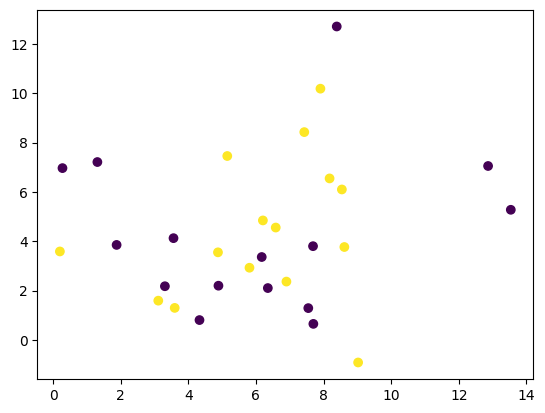

In [70]:
# Generate random Gaussian data with mean 5 and stdev 3 in both x and y
rng = np.random.default_rng()
x_r = rng.normal(loc=5, scale=3, size=(30,))
y_r = rng.normal(loc=5, scale=3, size=(30,))

# Very useful for this class: if you want to color-code
# scatter plot values, use the c= optional paramerer of plt.scatter
# TODO: Generate random integer values, make colored scatter plot below
ints = rng.integers(low = 0, high = 2, size=(30,))
print(ints)
plt.scatter(x_r, y_r, c=ints)
plt.show()

## 3: pandas

**Remember:** pandas holds 2D table data and works like your CS251/CS252 `Data` class.

In [71]:
import pandas as pd

/var/folders/59/kb315h4121n8mknx9yhv95br0000gn/T/ipykernel_97231/4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Load data with `read_csv`

Let's load in fMRI data in CSV format that is located in the data folder within the working directory


- `head()` method shows us the first few rows of the data
- `tail()` method shows us the last few rows of the data

In [74]:
df = pd.read_csv('Review/data/fmri.csv')
df.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


If the CSV file doesn't have headers, the import can look wonky:

In [75]:
df2 = pd.read_csv('Review/data/fmri_no_headers.csv')
df2.head()

,s13,18,stim,parietal,-0.017551581538
0,s5,14,stim,parietal,-0.080883
1,s12,18,stim,parietal,-0.081033
2,s11,18,stim,parietal,-0.046134
3,s10,18,stim,parietal,-0.037970
4,s9,18,stim,parietal,-0.103513


We can fix that with the `header=None` optional argument. We can also give it a list of custom headers with `names` 

(e.g. `['F1', 'F2', 'F3', 'F4', 'F5']`)

In [77]:
df2 = pd.read_csv('Review/data/fmri_no_headers.csv', header=None)
df2 = pd.read_csv('Review/data/fmri_no_headers.csv', header=None, names=['F1', 'F2', 'F3', 'F4', 'F5'])
df2.head()

,F1,F2,F3,F4,F5
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


**NOTE:** We can give `read_csv` a URL string of the CSV file from the internet and it will automatically download and load it in for us!


- `read_csv` has lots of optional parameters to handle stuff like skipping the first N rows of data (if there's metadata), using a non-comma delimiter, etc. Check out the massive documentation page: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html

### Convert categorical feature to int-coded feature

Let's take the categorical (string) feature `region` and map it to an int-code (0->frontal, 1->parietal)

In [81]:
# Convert region to categorical data type
df['region'] = pd.Categorical(df['region'])

# replace strings with their int categorical codes
df['region'] = df['region'].cat.codes
df['region']


0       1
1       1
2       1
3       1
4       1
       ..
1059    0
1060    0
1061    0
1062    0
1063    1
Name: region, Length: 1064, dtype: int8

### Convert `pandas DataFrame` -> numpy array

Convert entire `DataFrame`

In [82]:
df.to_numpy()

array([['s13', 18, 'stim', 1, -0.017551581538],
       ['s5', 14, 'stim', 1, -0.0808829319505],
       ['s12', 18, 'stim', 1, -0.0810330187333],
       ...,
       ['s12', 7, 'cue', 0, -0.00493910613621],
       ['s11', 7, 'cue', 0, -0.0253667098182],
       ['s0', 0, 'cue', 1, -0.00689923478092]], dtype=object)

#### or easily export the `DataFrame`  as a csv file

In [83]:
df.to_csv('test.csv')